In [1]:
import os
path="/Users/hassankhalid/Downloads/chest_xray"
print(os.listdir(path))

['.DS_Store', 'test', 'chest_xray', '__MACOSX', 'train', 'val']


In [2]:
for root, dirs, files in os.walk(path):
    print(root, len(files))

/Users/hassankhalid/Downloads/chest_xray 1
/Users/hassankhalid/Downloads/chest_xray/test 1
/Users/hassankhalid/Downloads/chest_xray/test/PNEUMONIA 390
/Users/hassankhalid/Downloads/chest_xray/test/NORMAL 234
/Users/hassankhalid/Downloads/chest_xray/chest_xray 1
/Users/hassankhalid/Downloads/chest_xray/chest_xray/test 1
/Users/hassankhalid/Downloads/chest_xray/chest_xray/test/PNEUMONIA 390
/Users/hassankhalid/Downloads/chest_xray/chest_xray/test/NORMAL 234
/Users/hassankhalid/Downloads/chest_xray/chest_xray/train 1
/Users/hassankhalid/Downloads/chest_xray/chest_xray/train/PNEUMONIA 3876
/Users/hassankhalid/Downloads/chest_xray/chest_xray/train/NORMAL 1342
/Users/hassankhalid/Downloads/chest_xray/chest_xray/val 1
/Users/hassankhalid/Downloads/chest_xray/chest_xray/val/PNEUMONIA 9
/Users/hassankhalid/Downloads/chest_xray/chest_xray/val/NORMAL 9
/Users/hassankhalid/Downloads/chest_xray/__MACOSX 0
/Users/hassankhalid/Downloads/chest_xray/__MACOSX/chest_xray 0
/Users/hassankhalid/Downloads/c

In [3]:
train_path = path + "/train"
test_path = path + "/test"
val_path = path + "/val"

import os
from PIL import Image

train_normal = os.path.join(train_path, "NORMAL")
train_pneumonia = os.path.join(train_path, "PNEUMONIA")

normal_file = os.listdir(train_normal)[0]
pneumonia_file = os.listdir(train_pneumonia)[0]

normal_img = Image.open(os.path.join(train_normal, normal_file))
pneumonia_img = Image.open(os.path.join(train_pneumonia, pneumonia_file))

print("Normal image:")
print("Size:", normal_img.size)
print("Mode:", normal_img.mode)

print("\nPneumonia image:")
print("Size:", pneumonia_img.size)
print("Mode:", pneumonia_img.mode)

Normal image:
Size: (2359, 2234)
Mode: L

Pneumonia image:
Size: (1048, 736)
Mode: L


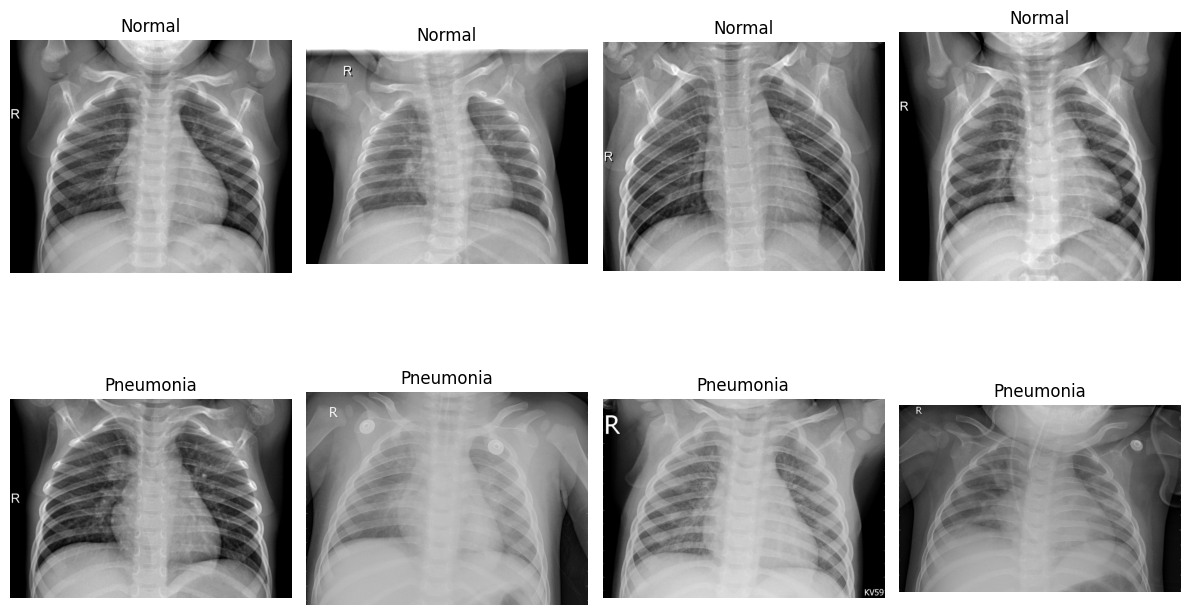

In [4]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

plt.figure(figsize=(12, 8))

for i in range(4):
    filename = random.choice(os.listdir(train_normal))
    image = Image.open(os.path.join(train_normal, filename))

    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title("Normal")
    plt.axis("off")

for i in range(4):
    filename = random.choice(os.listdir(train_pneumonia))
    image = Image.open(os.path.join(train_pneumonia, filename))

    plt.subplot(2, 4, i + 5)
    plt.imshow(image, cmap="gray")
    plt.title("Pneumonia")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
import os
from sklearn.model_selection import train_test_split

normal_path = os.path.join(train_path, "NORMAL")
pneumonia_path = os.path.join(train_path, "PNEUMONIA")

normal_images = [os.path.join(normal_path, f)
                 for f in os.listdir(normal_path)]

pneumonia_images = [os.path.join(pneumonia_path, f)
                    for f in os.listdir(pneumonia_path)]

images = normal_images + pneumonia_images
labels = [0] * len(normal_images) + [1] * len(pneumonia_images)

X_train, X_val, y_train, y_val = train_test_split(
    images,
    labels,
    test_size=0.10,
    stratify=labels,
    random_state=42
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))

Training images: 4694
Validation images: 522


In [6]:
import tensorflow as tf
import numpy as np

print(tf.__version__)

2.16.2


/Users/hassankhalid/tf_env/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [8]:
def load_image(path, label):
    
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image,channels=1)
    image = tf.image.resize(image,IMG_SIZE)   
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [9]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))

2026-08-16 17:49:13.950561: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-08-16 17:49:13.950767: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-08-16 17:49:13.950782: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-08-16 17:49:13.951036: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-16 17:49:13.951302: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
train_ds = train_ds.map(load_image,num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(load_image,num_parallel_calls=AUTOTUNE)

In [11]:
train_ds = train_ds.shuffle(buffer_size=len(X_train))
train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [12]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel minimum:", tf.reduce_min(images).numpy())
    print("Pixel maximum:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 1)
Label batch shape: (32,)
Pixel minimum: 0.0
Pixel maximum: 1.0


2026-08-16 17:50:55.885506: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.05,width_factor=0.05)]) 

In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train)

class_weights = {0: class_weights[0],
                 1: class_weights[1]}

print(class_weights)

{0: 1.944490472245236, 1: 0.6730714080871809}


In [15]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224, 224, 1)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,209 (430.50 KB)

 Trainable params: 109,761 (428.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")]) 

In [17]:
callbacks = [tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        "best_cnn.keras",
        monitor="val_loss",
        save_best_only=True)] 

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/30


2026-08-16 17:57:28.374007: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


147/147 ━━━━━━━━━━━━━━━━━━━━ 68s 377ms/step - accuracy: 0.8063 - loss: 0.4224 - precision: 0.9405 - recall: 0.7892 - val_accuracy: 0.7433 - val_loss: 0.5954 - val_precision: 0.7433 - val_recall: 1.0000
Epoch 2/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 63s 370ms/step - accuracy: 0.8519 - loss: 0.3453 - precision: 0.9589 - recall: 0.8365 - val_accuracy: 0.7433 - val_loss: 0.8487 - val_precision: 0.7433 - val_recall: 1.0000
Epoch 3/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 67s 394ms/step - accuracy: 0.8441 - loss: 0.4024 - precision: 0.9575 - recall: 0.8268 - val_accuracy: 0.3831 - val_loss: 1.6366 - val_precision: 1.0000 - val_recall: 0.1701
Epoch 4/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 72s 426ms/step - accuracy: 0.8551 - loss: 0.3719 - precision: 0.9582 - recall: 0.8417 - val_accuracy: 0.3065 - val_loss: 4.9059 - val_precision: 1.0000 - val_recall: 0.0670


In [19]:
print("Best validation loss:")
print(min(history.history["val_loss"]))

print("Best validation accuracy:")
print(max(history.history["val_accuracy"]))

Best validation loss:
0.5953885316848755
Best validation accuracy:
0.7432950139045715


In [20]:
best_epoch = np.argmin(history.history["val_loss"]) + 1
print("Best epoch:", best_epoch)

Best epoch: 1


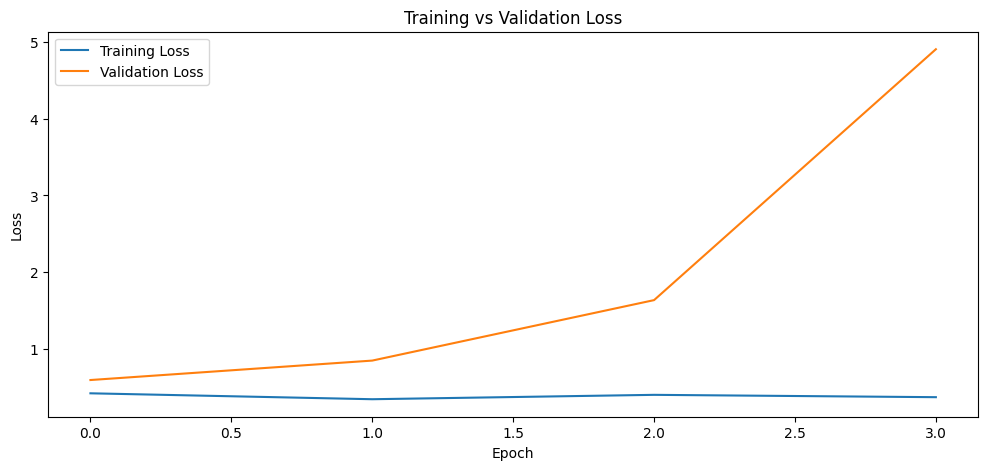

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

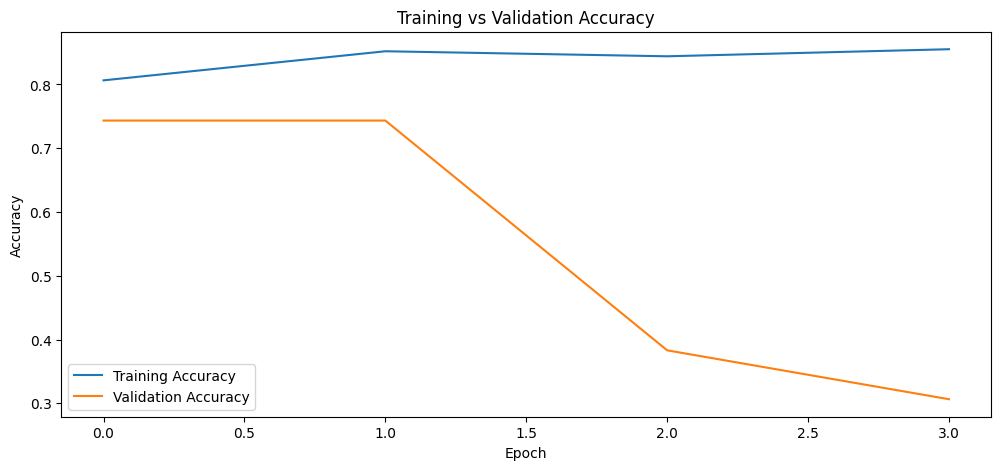

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [23]:
test_normal_path = os.path.join(test_path, "NORMAL")
test_pneumonia_path = os.path.join(test_path, "PNEUMONIA")

test_normal_images = [
    os.path.join(test_normal_path, f)
    for f in os.listdir(test_normal_path)
]

test_pneumonia_images = [
    os.path.join(test_pneumonia_path, f)
    for f in os.listdir(test_pneumonia_path)
]

X_test = test_normal_images + test_pneumonia_images
y_test = [0] * len(test_normal_images) + [1] * len(test_pneumonia_images)

print("Test images:", len(X_test))
print("Normal:", len(test_normal_images))
print("Pneumonia:", len(test_pneumonia_images))

Test images: 624
Normal: 234
Pneumonia: 390


In [24]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [25]:
best_model = tf.keras.models.load_model("best_cnn.keras")
test_results = best_model.evaluate(test_ds)
print(test_results)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.6250 - loss: 0.6558 - precision: 0.6250 - recall: 1.0000
[0.6557981967926025, 0.625, 0.625, 1.0]


In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)

    predictions = (predictions >= 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

cm = confusion_matrix(y_true, y_pred)

print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

[[  0 234]
 [  0 390]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
   PNEUMONIA       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



2026-08-16 18:07:56.006684: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/hassankhalid/tf_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hassankhalid/tf_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hassankhalid/tf_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in lab

In [27]:
for images, labels in test_ds.take(1):
    predictions = best_model.predict(images, verbose=0).flatten()

    print(predictions[:20])
    print("Minimum:", predictions.min())
    print("Maximum:", predictions.max())

[0.59383416 0.5892354  0.57330745 0.5840146  0.62262    0.58957016
 0.6101585  0.5984548  0.5941919  0.59356666 0.5878294  0.5883125
 0.5948531  0.5881386  0.57988536 0.588037   0.59266216 0.59761804
 0.58144265 0.5703347 ]
Minimum: 0.5703347
Maximum: 0.64266014


2026-08-16 18:08:39.485215: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [28]:
def load_image_rgb(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image,channels=3)
    image = tf.image.resize(image,IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label

In [29]:
train_ds_mn = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

val_ds_mn = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

In [30]:
train_ds_mn = train_ds_mn.map(
    load_image_rgb,
    num_parallel_calls=AUTOTUNE
)

val_ds_mn = val_ds_mn.map(
    load_image_rgb,
    num_parallel_calls=AUTOTUNE
)

In [31]:
train_ds_mn = train_ds_mn.shuffle(buffer_size=len(X_train))
train_ds_mn = train_ds_mn.batch(BATCH_SIZE)
val_ds_mn = val_ds_mn.batch(BATCH_SIZE)

train_ds_mn = train_ds_mn.prefetch(AUTOTUNE)
val_ds_mn = val_ds_mn.prefetch(AUTOTUNE)

In [32]:
for images, labels in train_ds_mn.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel minimum:", tf.reduce_min(images).numpy())
    print("Pixel maximum:", tf.reduce_max(images).numpy())

2026-08-16 18:11:37.208247: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:301: Filling up shuffle buffer (this may take a while): 4330 of 4694
2026-08-16 18:11:38.114427: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel minimum: 0.0
Pixel maximum: 255.0


2026-08-16 18:11:38.763991: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [33]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3))

base_model.trainable = False

print("Base model parameters:", base_model.count_params())

Base model parameters: 2257984


In [34]:
from tensorflow.keras import layers, models

inputs = layers.Input(shape=(224, 224, 3))


x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

mobilenet_model = models.Model(inputs, outputs)

mobilenet_model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [35]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [36]:
mobilenet_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_mobilenet.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [37]:
mobilenet_history = mobilenet_model.fit(
    train_ds_mn,
    validation_data=val_ds_mn,
    epochs=15,
    class_weight=class_weights,
    callbacks=mobilenet_callbacks
)

Epoch 1/15


2026-08-16 18:14:13.218776: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:301: Filling up shuffle buffer (this may take a while): 4142 of 4694
2026-08-16 18:14:14.590352: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


147/147 ━━━━━━━━━━━━━━━━━━━━ 67s 347ms/step - accuracy: 0.6866 - loss: 0.6629 - precision: 0.8098 - recall: 0.7557 - val_accuracy: 0.8525 - val_loss: 0.4858 - val_precision: 0.9560 - val_recall: 0.8402
Epoch 2/15


2026-08-16 18:15:18.220098: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:301: Filling up shuffle buffer (this may take a while): 3056 of 4694
2026-08-16 18:15:23.135777: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


147/147 ━━━━━━━━━━━━━━━━━━━━ 77s 422ms/step - accuracy: 0.7899 - loss: 0.4817 - precision: 0.9175 - recall: 0.7881 - val_accuracy: 0.9100 - val_loss: 0.3630 - val_precision: 0.9885 - val_recall: 0.8892
Epoch 3/15


...

147/147 ━━━━━━━━━━━━━━━━━━━━ 68s 362ms/step - accuracy: 0.9365 - loss: 0.1682 - precision: 0.9845 - recall: 0.9292 - val_accuracy: 0.9713 - val_loss: 0.1142 - val_precision: 0.9947 - val_recall: 0.9665
Epoch 14/15


2026-08-16 18:30:00.733678: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:301: Filling up shuffle buffer (this may take a while): 2555 of 4694
2026-08-16 18:30:08.510532: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


147/147 ━━━━━━━━━━━━━━━━━━━━ 81s 425ms/step - accuracy: 0.9357 - loss: 0.1634 - precision: 0.9818 - recall: 0.9306 - val_accuracy: 0.9693 - val_loss: 0.1215 - val_precision: 1.0000 - val_recall: 0.9588
Epoch 15/15


2026-08-16 18:31:21.433103: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:301: Filling up shuffle buffer (this may take a while): 2387 of 4694
2026-08-16 18:31:29.206879: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


147/147 ━━━━━━━━━━━━━━━━━━━━ 79s 416ms/step - accuracy: 0.9393 - loss: 0.1606 - precision: 0.9843 - recall: 0.9332 - val_accuracy: 0.9770 - val_loss: 0.1091 - val_precision: 1.0000 - val_recall: 0.9691


In [38]:
best_mobilenet = tf.keras.models.load_model("best_mobilenet.keras")

In [39]:
test_ds_mn = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

test_ds_mn = test_ds_mn.map(
    load_image_rgb,
    num_parallel_calls=AUTOTUNE
)

test_ds_mn = test_ds_mn.batch(BATCH_SIZE)
test_ds_mn = test_ds_mn.prefetch(AUTOTUNE)

In [40]:
test_results_mn = best_mobilenet.evaluate(test_ds_mn)

print(test_results_mn)

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 406ms/step - accuracy: 0.8638 - loss: 0.3101 - precision: 0.8381 - recall: 0.9692
[0.31007733941078186, 0.8637820482254028, 0.8381374478340149, 0.9692307710647583]


In [41]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds_mn:
    predictions = best_mobilenet.predict(images, verbose=0).flatten()

    predictions = (predictions >= 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

Confusion Matrix:
[[161  73]
 [ 12 378]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.93      0.69      0.79       234
   PNEUMONIA       0.84      0.97      0.90       390

    accuracy                           0.86       624
   macro avg       0.88      0.83      0.85       624
weighted avg       0.87      0.86      0.86       624



2026-08-16 18:34:33.056351: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [42]:
y_true = []
y_prob = []

for images, labels in test_ds_mn:
    predictions = best_mobilenet.predict(images, verbose=0).flatten()

    y_true.extend(labels.numpy())
    y_prob.extend(predictions)

y_true = np.array(y_true)
y_prob = np.array(y_prob)

print("Number of predictions:", len(y_prob))
print("Minimum probability:", y_prob.min())
print("Maximum probability:", y_prob.max())

Number of predictions: 624
Minimum probability: 0.0017255363
Maximum probability: 0.9998896


2026-08-16 18:36:25.738609: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Accuracy: {accuracy:.3f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.30 | Accuracy: 0.814 | Precision: 0.775 | Recall: 0.990 | F1: 0.869
Threshold: 0.40 | Accuracy: 0.841 | Precision: 0.805 | Recall: 0.985 | F1: 0.886
Threshold: 0.50 | Accuracy: 0.864 | Precision: 0.838 | Recall: 0.969 | F1: 0.899
Threshold: 0.60 | Accuracy: 0.880 | Precision: 0.864 | Recall: 0.959 | F1: 0.909
Threshold: 0.70 | Accuracy: 0.888 | Precision: 0.898 | Recall: 0.926 | F1: 0.912
Threshold: 0.80 | Accuracy: 0.894 | Precision: 0.935 | Recall: 0.892 | F1: 0.913


In [44]:
y_val_true = []
y_val_prob = []

for images, labels in val_ds_mn:
    predictions = best_mobilenet.predict(images, verbose=0).flatten()

    y_val_true.extend(labels.numpy())
    y_val_prob.extend(predictions)

y_val_true = np.array(y_val_true)
y_val_prob = np.array(y_val_prob)

print("Validation predictions:", len(y_val_prob))

Validation predictions: 522


2026-08-16 18:37:52.569122: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [45]:
thresholds = np.arange(0.30, 0.91, 0.05)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:

    y_pred = (y_val_prob >= threshold).astype(int)

    f1 = f1_score(
        y_val_true,
        y_pred,
        zero_division=0
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

    print(
        f"Threshold: {threshold:.2f} | "
        f"F1: {f1:.3f}"
    )

print("\nBest threshold:", best_threshold)
print("Best validation F1:", best_f1)

Threshold: 0.30 | F1: 0.992
Threshold: 0.35 | F1: 0.988
Threshold: 0.40 | F1: 0.987
Threshold: 0.45 | F1: 0.984
Threshold: 0.50 | F1: 0.984
Threshold: 0.55 | F1: 0.979
Threshold: 0.60 | F1: 0.969
Threshold: 0.65 | F1: 0.967
Threshold: 0.70 | F1: 0.956
Threshold: 0.75 | F1: 0.931
Threshold: 0.80 | F1: 0.912
Threshold: 0.85 | F1: 0.898
Threshold: 0.90 | F1: 0.850

Best threshold: 0.3
Best validation F1: 0.9922680412371134


In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

threshold = 0.30

y_test_pred = (y_prob >= threshold).astype(int)

print("Threshold:", threshold)
print("Accuracy:", accuracy_score(y_true, y_test_pred))
print("Precision:", precision_score(y_true, y_test_pred))
print("Recall:", recall_score(y_true, y_test_pred))
print("F1:", f1_score(y_true, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_test_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_test_pred,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

Threshold: 0.3
Accuracy: 0.8141025641025641
Precision: 0.7751004016064257
Recall: 0.9897435897435898
F1: 0.8693693693693694

Confusion Matrix:
[[122 112]
 [  4 386]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.52      0.68       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.81       624
   macro avg       0.87      0.76      0.77       624
weighted avg       0.85      0.81      0.80       624



In [47]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Trainable layers:",
      sum(layer.trainable for layer in base_model.layers))

Trainable layers: 19


In [48]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [49]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_mobilenet_finetuned.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [50]:
fine_tune_history = mobilenet_model.fit(
    train_ds_mn,
    validation_data=val_ds_mn,
    epochs=10,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks
)

Epoch 1/10


2026-08-16 18:40:58.525663: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:301: Filling up shuffle buffer (this may take a while): 3111 of 4694
2026-08-16 18:41:03.566826: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


147/147 ━━━━━━━━━━━━━━━━━━━━ 96s 488ms/step - accuracy: 0.9546 - loss: 0.1133 - precision: 0.9849 - recall: 0.9535 - val_accuracy: 0.9923 - val_loss: 0.0381 - val_precision: 1.0000 - val_recall: 0.9897
Epoch 2/10


2026-08-16 18:42:31.778405: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:301: Filling up shuffle buffer (this may take a while): 2441 of 4694
2026-08-16 18:42:40.805613: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


147/147 ━━━━━━━━━━━━━━━━━━━━ 101s 541ms/step - accuracy: 0.9706 - loss: 0.0790 - precision: 0.9918 - recall: 0.9685 - val_accuracy: 0.9904 - val_loss: 0.0332 - val_precision: 1.0000 - val_recall: 0.9871
Epoch 3/10


...

147/147 ━━━━━━━━━━━━━━━━━━━━ 94s 523ms/step - accuracy: 0.9917 - loss: 0.0240 - precision: 0.9991 - recall: 0.9897 - val_accuracy: 0.9981 - val_loss: 0.0173 - val_precision: 1.0000 - val_recall: 0.9974
Epoch 9/10


2026-08-16 18:53:29.949444: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:301: Filling up shuffle buffer (this may take a while): 2307 of 4694
2026-08-16 18:53:38.840435: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


147/147 ━━━━━━━━━━━━━━━━━━━━ 91s 487ms/step - accuracy: 0.9945 - loss: 0.0186 - precision: 1.0000 - recall: 0.9925 - val_accuracy: 0.9943 - val_loss: 0.0161 - val_precision: 1.0000 - val_recall: 0.9923
Epoch 10/10


2026-08-16 18:55:00.809417: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:301: Filling up shuffle buffer (this may take a while): 2809 of 4694
2026-08-16 18:55:07.159472: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


147/147 ━━━━━━━━━━━━━━━━━━━━ 100s 571ms/step - accuracy: 0.9932 - loss: 0.0167 - precision: 0.9983 - recall: 0.9925 - val_accuracy: 0.9923 - val_loss: 0.0191 - val_precision: 0.9974 - val_recall: 0.9923


In [51]:
best_finetuned = tf.keras.models.load_model(
    "best_mobilenet_finetuned.keras"
)

In [52]:
finetuned_test_results = best_finetuned.evaluate(test_ds_mn)

print(finetuned_test_results)

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 485ms/step - accuracy: 0.8189 - loss: 0.9465 - precision: 0.7764 - recall: 0.9974
[0.946488082408905, 0.8189102411270142, 0.7764471173286438, 0.9974358677864075]


In [53]:
y_true_ft = []
y_prob_ft = []

for images, labels in test_ds_mn:
    predictions = best_finetuned.predict(
        images,
        verbose=0
    ).flatten()

    y_true_ft.extend(labels.numpy())
    y_prob_ft.extend(predictions)

y_true_ft = np.array(y_true_ft)
y_prob_ft = np.array(y_prob_ft)

y_pred_ft = (y_prob_ft >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_true_ft, y_pred_ft))

print("\nClassification Report:")
print(
    classification_report(
        y_true_ft,
        y_pred_ft,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

Confusion Matrix:
[[122 112]
 [  1 389]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.99      0.52      0.68       234
   PNEUMONIA       0.78      1.00      0.87       390

    accuracy                           0.82       624
   macro avg       0.88      0.76      0.78       624
weighted avg       0.86      0.82      0.80       624



2026-08-16 18:58:24.802273: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [54]:
best_mobilenet.save("pneumonia_mobilenet.keras")

In [55]:
final_model = tf.keras.models.load_model("best_mobilenet.keras")

final_model.save("pneumonia_mobilenet.keras")

print("Final model saved successfully.")

Final model saved successfully.


## Project Summary & Model Selection

- **Dataset:** Chest X-ray dataset containing two classes: NORMAL and PNEUMONIA.

- The dataset contained approximately **5,216 training images**, **16 validation images**, and **624 test images** in the original directory structure. For model development, the training data was reorganized into training and validation subsets, resulting in approximately **4,694 training images and 522 validation images**.

- **Image preprocessing:** X-ray images were resized to **224 × 224 pixels**. The original grayscale images were converted to 3-channel images for compatibility with MobileNetV2.

- **Class imbalance:** The training dataset contained substantially more PNEUMONIA images than NORMAL images. Class weights were therefore calculated and incorporated during training to reduce the effect of class imbalance.

- **Model 1 — Custom CNN:** A CNN was developed from scratch using convolutional layers, batch normalization, max pooling, global average pooling, dropout, and a dense output layer.

- The Custom CNN achieved approximately **62.5% test accuracy**, but analysis of the confusion matrix showed that it predicted almost every test image as PNEUMONIA. Therefore, the model had poor class discrimination.

- **Model 2 — MobileNetV2 Transfer Learning:** MobileNetV2 pretrained on ImageNet was used as a frozen feature extractor with a custom binary classification head.

- During the initial transfer-learning stage, only the newly added classification layers were trained. The model achieved approximately **86.4% test accuracy**, with **96.9% recall for PNEUMONIA** and a PNEUMONIA F1-score of approximately **0.90**.

- **Threshold analysis:** Different classification thresholds were investigated instead of relying only on the default 0.5 threshold. Lower thresholds increased pneumonia recall but also produced substantially more false positives. The default **0.5 threshold** provided a better overall balance for the final model.

- **Model 3 — Fine-tuned MobileNetV2:** The upper layers of MobileNetV2 were unfrozen and fine-tuned using a very small learning rate.

- Although fine-tuning produced extremely strong validation performance, the model achieved only approximately **81.9% test accuracy**. Recall increased to approximately **99.7%**, but precision and overall generalization decreased.

- **Final Model Selection:** The original frozen MobileNetV2 transfer-learning model was selected as the final model because it demonstrated better performance on the unseen test dataset and provided a better balance between accuracy, precision, recall, and F1-score.

- **Final Test Performance:**
  - Accuracy: **86.38%**
  - Precision: **83.81%**
  - Recall: **96.92%**
  - PNEUMONIA F1-score: **0.90**
  - Macro F1-score: **0.85**

- The final model was saved in **Keras `.keras` format** and will be used for deployment through a **FastAPI REST API**.

- **Next Steps:** Develop a FastAPI endpoint that accepts an X-ray image, performs the same preprocessing used during training, loads the saved MobileNetV2 model, and returns the predicted class and probability. The API will subsequently be containerized using Docker.